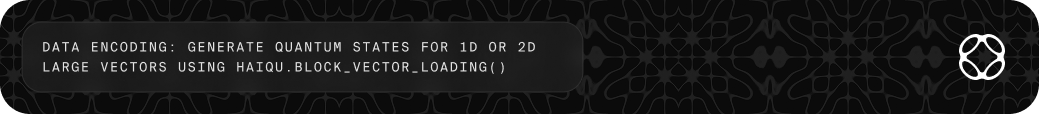

This notebook demonstrates how to use `haiqu.block_vector_loading()` to generate a quantum state for 1D and 2D large vectors with high fidelity. It slices the input vector or matrix into blocks, which are encoded independently. The method introduces a trade-off between loading smaller and simpler vectors into a quantum state but requiring more qubits to do so.

- For the 64x64 pixels image Vector Loading prepares a state with ~87% fidelity, while Block Vector Loading achieves ~97% fidelity.

### `haiqu.block_vector_loading()`

- **What does it do?** Block Vector loading prepares a quantum state, which amplitudes match a given data vector, sliced into multiple blocks.
- **How do I use it?** Pass a real or complex vector or matrix and desired number of blocks to create a data loading job, then retrieve results with `job.result()`.
- **What are the options?** Optional parameters include various hyperparameters for circuit synthesis such as `num_layers`, `truncation_cutoff` and `fine_tuning_iterations`.
- **Which option do you recommend?** Start with few blocks and observe the state `fidelity` returned by the job result as well as number of qubits required. If needed try to increase amount of blocks and synthesis parameters to achieve the desired fidelity.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

## Initialize the benchmark

Import the necessary libraries, initialize the Haiqu SDK, create a desired quantum state.

> Note: this notebook requires `scikit-image` package to be installed. Make sure that you have run `pip install -r requirements.txt` or `pip install scikit-image` before attempting to run this notebook.

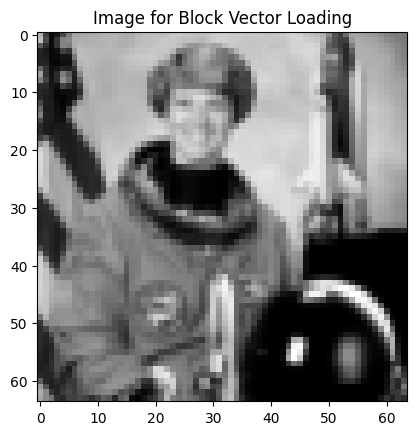

In [1]:
import qiskit
import numpy as np
import pandas as pd
from haiqu.sdk import haiqu
import matplotlib.pyplot as plt
from skimage import data, color, transform
from qiskit.circuit.library import StatePreparation

haiqu.login()
haiqu.init("Block Vector Loading Tutorial")

target_size = 64

image_rgb = data.astronaut()
image_gray = color.rgb2gray(image_rgb)
image_resized = transform.resize(image_gray, (target_size, target_size), anti_aliasing=True)

plt.imshow(image_resized, cmap='gray')
plt.title(f"Image for Block Vector Loading")
plt.show()

## Run benchmark scenarios

Prepare a quantum state with Qiskit's default and Haiqu's methods

In [2]:
# Scenario 1: standard method
qiskit_sp = StatePreparation(image_resized.ravel(), normalize=True)
circuit_qiskit = qiskit.QuantumCircuit(qiskit_sp.num_qubits, name="Qiskit")
circuit_qiskit.compose(qiskit_sp, inplace=True)

# Scenario 2: Haiqu vector loading
vector_job = haiqu.vector_loading(data=image_resized.ravel())
state_gate = vector_job.result()
circuit_vector = qiskit.QuantumCircuit(state_gate.num_qubits, name="VL")
circuit_vector.compose(state_gate, inplace=True)
print(f"Vector loading prepares the image with fidelity: {vector_job.info['fidelity']:.3f}")

# Scenario 3: Block Vector loading with 4x4 blocks
block_job = haiqu.block_vector_loading(data=image_resized.tolist(), num_blocks=(4, 4))
block_gate = block_job.result()
circuit_block = qiskit.QuantumCircuit(block_gate.num_qubits, name="BVL")
circuit_block.compose(block_gate, inplace=True)
print(f"Block Vector loading prepares the image with fidelity: {block_job.info['fidelity']:.3f}")

Vector loading prepares the image with fidelity: 0.870
Block Vector loading prepares the image with fidelity: 0.964


Block Vector loading allows to load the image with a much better fidelity than standard Vector loading.

Haiqu's loading methods outperform standard method in circuit complexity as shown in the table below:

In [3]:
# we consider an ideal device with all-to-all connectivity
device_ideal = haiqu.get_device("aer_simulator")

circuit_qiskit_transpiled = haiqu.transpile(circuit_qiskit, device=device_ideal)

circuit_vector_transpiled = haiqu.transpile(circuit_vector, device=device_ideal)

circuit_block_transpiled = haiqu.transpile(circuit_block, device=device_ideal)

haiqu.compare_metrics(circuit_qiskit_transpiled, circuit_vector_transpiled, circuit_block_transpiled)

CIRCUIT,Qiskit-on-aer_simulator,VL-on-aer_simulator,BVL-on-aer_simulator
QUBITS,12,12,128
DEPTH,8167,31,23
2-Q GATES DEPTH,4083,15,11
1-Q GATES,4095,95,944
2-Q GATES,4083,42,416
GATES TOTAL,8178,137,1360


## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

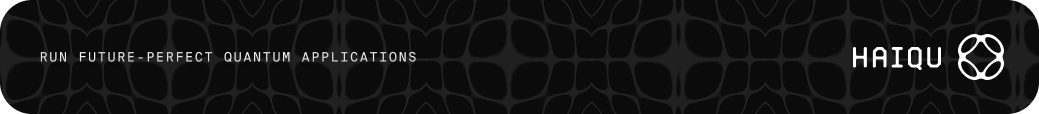